In [1]:
from gensim.models import Word2Vec

word2vec_model = Word2Vec.load("./unlabelled/10_epoch_embeddings_long_sentences.model")

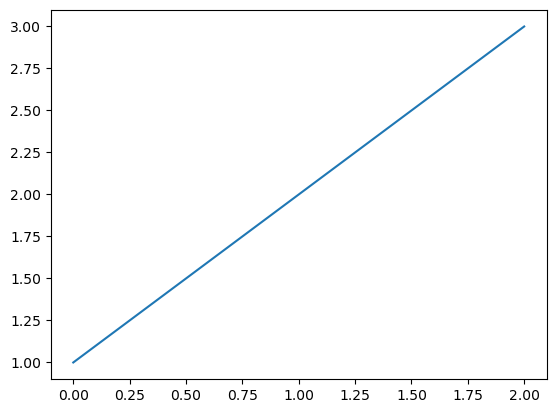

In [2]:
import matplotlib.pyplot as plt
plt.plot([1,2,3])

In [3]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

model_name = 'jbochi/madlad400-3b-mt'
#model = T5ForConditionalGeneration.from_pretrained(model_name, device_map=None)
tokenizer = T5Tokenizer.from_pretrained(model_name)


c:\Users\victo\anaconda3\envs\exam\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\victo\anaconda3\envs\exam\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\victo\.cache\huggingface\hub\models--jbochi--madlad400-3b-mt. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate devel

In [ ]:
sentence = "".join("假設 A 同 B 之間 有 座 好 高 嘅 山 ， 噉 就要 諗 吓 ， 條 路 應該 跨過 座 山 吖 ， 穿過 座 山 吖 ， 定係 直接 兜 過 座 山 呢 ？".split(" "))
print(len(tokenizer(sentence)["input_ids"]))
print(len(sentence))

52
46


In [41]:
ts = []
for t in tokenizer(sentence)["input_ids"]:
    ts.append(tokenizer.decode(t))
    print(str(t) + " - " + tokenizer.decode(t))

print(" ".join(ts))

805 - 
38597 - 假
25268 - 設
1026 - A
5836 - 同
1451 - B
5088 - 之
13561 - 間
1993 - 有
22569 - 座
5123 - 好
4421 - 高
250846 - 嘅
8418 - 山
1088 - ，
778 - �
702 - �
686 - �
5350 - 就
4394 - 要
781 - �
720 - �
700 - �
248891 - 吓
1088 - ，
57771 - 條
8981 - 路
25491 - 應
37759 - 該
127012 - 跨
8682 - 過
22569 - 座
8418 - 山
255251 - 吖
1088 - ，
67892 - 穿
8682 - 過
22569 - 座
8418 - 山
255251 - 吖
1088 - ，
4750 - 定
73348 - 係
10351 - 直
9516 - 接
249118 - 兜
8682 - 過
22569 - 座
8418 - 山
37101 - 呢
8370 - ？
2 - </s>
 假 設 A 同 B 之 間 有 座 好 高 嘅 山 ， � � � 就 要 � � � 吓 ， 條 路 應 該 跨 過 座 山 吖 ， 穿 過 座 山 吖 ， 定 係 直 接 兜 過 座 山 呢 ？ </s>


In [40]:
tokenizer(sentence)["input_ids"]

[805,
 38597,
 25268,
 1026,
 5836,
 1451,
 5088,
 13561,
 1993,
 22569,
 5123,
 4421,
 250846,
 8418,
 1088,
 778,
 702,
 686,
 5350,
 4394,
 781,
 720,
 700,
 248891,
 1088,
 57771,
 8981,
 25491,
 37759,
 127012,
 8682,
 22569,
 8418,
 255251,
 1088,
 67892,
 8682,
 22569,
 8418,
 255251,
 1088,
 4750,
 73348,
 10351,
 9516,
 249118,
 8682,
 22569,
 8418,
 37101,
 8370,
 2]

In [4]:
!pip install IProgress

In [5]:
import torch

In [6]:

text = "<2en> 羅漢係我兄弟，他成日在正午放風箏，就算天陰陰。"
input_ids = tokenizer(text, return_tensors="pt").input_ids

In [7]:
input_ids

tensor([[   805,     38,    805,  55031,  76718,  73348,   3803, 130895,  68540,
           1088,  10900,   3612,   2834,   2185,   6517,  77343,  11783,  26434,
         253412,   1088,   5350,  18635,   3911, 201462, 201462,   1142,      2]])

In [9]:
madlad_embeddings = torch.load("madlad_embedding.pth")

C:\Users\victo\AppData\Local\Temp\ipykernel_3688\1408872904.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  madlad_embeddings = torch.load("madlad_embedding.pth")


In [10]:
madlad_embeddings["weight"]

tensor([[-1.5856e-01, -3.5794e-01,  6.4598e-01,  ..., -2.7512e-02,
          4.7947e-01, -2.1065e-01],
        [ 1.6151e+00, -1.3196e+00, -1.1277e+00,  ...,  1.3023e+00,
          1.0067e-01,  5.4038e-03],
        [ 8.8776e-02,  7.7090e-01, -1.2226e+00,  ...,  6.7889e-01,
          8.6144e-01, -4.7935e-01],
        ...,
        [-1.2001e+01,  2.9804e+01,  4.8532e+00,  ...,  1.0312e+01,
         -2.9909e+00,  1.1952e+01],
        [-1.2817e+01, -1.7005e+01, -1.2661e+01,  ..., -2.4770e+01,
          5.4046e+00,  3.7453e+00],
        [ 4.5549e+00, -4.4047e+00,  4.4078e+00,  ...,  2.4507e+00,
          2.1307e+01, -9.2011e+00]])

In [11]:

def get_madlad_embedding_layer():
    return madlad_embeddings # decoder and encoder uses the same embedding weights
get_madlad_embedding_layer()["weight"].dtype

torch.float32

In [12]:
madlad_embeddings["weight"][input_ids]

tensor([[[ 1.6555e-01,  1.1890e+00, -2.1539e+00,  ..., -4.0582e+00,
           1.0744e+00, -5.7736e-01],
         [-3.9575e+00,  2.3815e-03,  1.6395e+00,  ...,  2.5391e+00,
          -1.6154e+01, -5.2441e+00],
         [ 1.6555e-01,  1.1890e+00, -2.1539e+00,  ..., -4.0582e+00,
           1.0744e+00, -5.7736e-01],
         ...,
         [ 2.3343e+00,  3.2717e+01,  7.6224e+00,  ...,  2.3185e+00,
          -1.1847e+01, -1.5596e+00],
         [-9.1812e+00,  1.7173e+01,  5.6834e+00,  ..., -1.1631e+01,
           2.9282e+00,  2.7449e+00],
         [ 8.8776e-02,  7.7090e-01, -1.2226e+00,  ...,  6.7889e-01,
           8.6144e-01, -4.7935e-01]]])

In [14]:
def get_madlad_embedding(token: str, include_start_and_end_tokens=False) -> torch.Tensor:
    '''
    [:, -1, :] is the EOF token embedding
    '''
    input_ids = tokenizer(token, return_tensors="pt").input_ids
    
    if not include_start_and_end_tokens:
        input_ids = input_ids[input_ids != 2]
        input_ids = input_ids[input_ids != 805]
    
    embeddings = get_madlad_embedding_layer()["weight"][input_ids]
    
    return embeddings


start_token = (get_madlad_embedding(''))
embedding = get_madlad_embedding('<2en>')

embedding.shape, start_token.shape

(torch.Size([1, 1024]), torch.Size([0, 1024]))

In [15]:
from torch import nn
import numpy as np
import datasets
from datasets import DatasetDict
gatitos: DatasetDict = datasets.load_dataset("google/smol", "gatitos__yue_zh") # type: ignore

In [16]:
token_translations: list[dict[str, list[str]]] = []
for i in range(gatitos['train']['src'].__len__()): 
    for s in gatitos['train']['src'][i].split('; '):
        for t in gatitos['train']['trgs'][i]:
            token_translations.append({
                'src': s,
                'trg': t
            })

In [17]:
token_translations

[{'src': '廣州話', 'trg': '广州话'},
 {'src': '廣州話', 'trg': '广东话'},
 {'src': '廣州話', 'trg': '粤语'},
 {'src': '廣東話', 'trg': '广州话'},
 {'src': '廣東話', 'trg': '广东话'},
 {'src': '廣東話', 'trg': '粤语'},
 {'src': '粵語', 'trg': '广州话'},
 {'src': '粵語', 'trg': '广东话'},
 {'src': '粵語', 'trg': '粤语'},
 {'src': '白話', 'trg': '广州话'},
 {'src': '白話', 'trg': '广东话'},
 {'src': '白話', 'trg': '粤语'},
 {'src': '我', 'trg': '我'},
 {'src': '一', 'trg': '一'},
 {'src': '係', 'trg': '是'},
 {'src': '你好', 'trg': '你好'},
 {'src': '得', 'trg': '行'},
 {'src': '你點啊', 'trg': '你怎样啊'},
 {'src': '你好', 'trg': '你好'},
 {'src': '好嘅', 'trg': '好的'},
 {'src': '唔得', 'trg': '不行'},
 {'src': '多謝你', 'trg': '谢谢你'},
 {'src': '個', 'trg': '那个'},
 {'src': '你', 'trg': '你'},
 {'src': '早晨', 'trg': '早上好'},
 {'src': '乜嘢', 'trg': '什么'},
 {'src': '點解', 'trg': '为什么'},
 {'src': '好', 'trg': '好'},
 {'src': '喺', 'trg': '在'},
 {'src': '你最近點啊', 'trg': '你最近怎么样啊'},
 {'src': '點樣', 'trg': '怎么样'},
 {'src': '去', 'trg': '去'},
 {'src': '好', 'trg': '好'},
 {'src': '所以', 'trg': '所以'},
 {'

In [18]:
len(token_translations)

5351

In [23]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(token_translations, train_size=0.9, shuffle=True)

In [12]:
token_translations[0]["trg"]

'广州话'

In [27]:
import numpy as np

In [28]:
indices =np.where(np.array([x["trg"] in word2vec_model.wv for x in token_translations]) == True)

In [30]:
token_translations

[{'src': '廣州話', 'trg': '广州话'},
 {'src': '廣州話', 'trg': '广东话'},
 {'src': '廣州話', 'trg': '粤语'},
 {'src': '廣東話', 'trg': '广州话'},
 {'src': '廣東話', 'trg': '广东话'},
 {'src': '廣東話', 'trg': '粤语'},
 {'src': '粵語', 'trg': '广州话'},
 {'src': '粵語', 'trg': '广东话'},
 {'src': '粵語', 'trg': '粤语'},
 {'src': '白話', 'trg': '广州话'},
 {'src': '白話', 'trg': '广东话'},
 {'src': '白話', 'trg': '粤语'},
 {'src': '我', 'trg': '我'},
 {'src': '一', 'trg': '一'},
 {'src': '係', 'trg': '是'},
 {'src': '你好', 'trg': '你好'},
 {'src': '得', 'trg': '行'},
 {'src': '你點啊', 'trg': '你怎样啊'},
 {'src': '你好', 'trg': '你好'},
 {'src': '好嘅', 'trg': '好的'},
 {'src': '唔得', 'trg': '不行'},
 {'src': '多謝你', 'trg': '谢谢你'},
 {'src': '個', 'trg': '那个'},
 {'src': '你', 'trg': '你'},
 {'src': '早晨', 'trg': '早上好'},
 {'src': '乜嘢', 'trg': '什么'},
 {'src': '點解', 'trg': '为什么'},
 {'src': '好', 'trg': '好'},
 {'src': '喺', 'trg': '在'},
 {'src': '你最近點啊', 'trg': '你最近怎么样啊'},
 {'src': '點樣', 'trg': '怎么样'},
 {'src': '去', 'trg': '去'},
 {'src': '好', 'trg': '好'},
 {'src': '所以', 'trg': '所以'},
 {'

In [29]:
token_translations[int(indices[0][0])]["trg"] in word2vec_model.wv

True

In [42]:
test_token = token_translations[int(indices[0][0])]["trg"]

In [43]:
word2vec_model.wv[test_token]

array([ 0.01866808, -0.0612832 ,  0.10284466, ...,  0.00310392,
       -0.05295956,  0.11279958], shape=(1024,), dtype=float32)

In [44]:
get_madlad_embedding(test_token)

tensor([[ -1.7124,  19.3426, -12.8546,  ..., -14.0900,   9.3031,  -4.6456]])

In [85]:
torch.norm(torch.tensor(word2vec_model.wv[token_translations[int(indices[0][30])]["trg"]]) @ W.to('cpu') - get_madlad_embedding(token_translations[int(indices[0][30])]["src"])) ** 2

tensor(149086.5781, grad_fn=<PowBackward0>)

In [88]:
torch.norm(torch.tensor(word2vec_model.wv[token_translations[int(indices[0][30])]["trg"]]) @ W.to('cpu'))

tensor(182.9896, grad_fn=<LinalgVectorNormBackward0>)

In [89]:
torch.norm(get_madlad_embedding(token_translations[int(indices[0][30])]["src"]))

tensor(515.0342)

In [46]:
token_translations[indices[0][30]]

{'src': '喺', 'trg': '在'}

In [47]:
get_madlad_embedding(token_translations[int(indices[0][1])]["src"])

tensor([[-19.9191, -10.8058,  15.6723,  ...,   2.8460, -21.4432,  -8.5228]])

In [173]:
len(token_translations)

5351

In [189]:
len([x for x in token_translations if x["trg"] in word2vec_model.wv])

2251

In [49]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [50]:
device

'cuda'

In [72]:
epochs = 100
lr = 10**-3
train_losses=[]
test_losses=[]

from tqdm import tqdm

#W = torch.randn((1024, 1024))
W = torch.eye(1024, requires_grad=True, device=device)
optim = torch.optim.Adam([W], lr=lr)
#criterion = nn.MSELoss()
batchsize = 64


In [71]:
def criterion(X, W, Y): 
    pred = X @ W
    targets = Y
    diff = torch.norm(pred - targets,dim=1)
    loss = diff @ diff

    return loss


In [93]:
for epoch in tqdm(range(epochs)):
    epoch_loss = 0
    j = 0
    for i in range(0, len(train_data), batchsize):
        existing_indices = [x for x in range(i, min(i+batchsize, len(train_data))) if train_data[x]["trg"] in word2vec_model.wv]
        #print(existing_indices)
        #if train_data[i]["trg"] in word2vec_model.wv:
        mandarin_embeddings = torch.stack([torch.mean(get_madlad_embedding(train_data[x]['src']),dim=0) for x in existing_indices]).to(device)
        cantonese_embeddings = torch.stack([torch.tensor(word2vec_model.wv[train_data[x]['trg']]) for x in existing_indices]).to(device)
        
        optim.zero_grad()
        loss = criterion(cantonese_embeddings, W, mandarin_embeddings)

        loss.backward()
        optim.step()
        epoch_loss += loss.item() 
        j = j + len(existing_indices)
    epoch_loss = epoch_loss / j

    if epoch % 10 == 0:
        test_loss = 0
        j = 0
        for i in range(0, len(test_data), batchsize):
            existing_indices = [x for x in range(i, min(i+batchsize, len(test_data))) if test_data[x]["trg"] in word2vec_model.wv]
            mandarin_embeddings = torch.stack([torch.mean(get_madlad_embedding(test_data[x]['src']),dim=0) for x in existing_indices]).to(device)
            cantonese_embeddings = torch.stack([torch.tensor(word2vec_model.wv[test_data[x]['trg']]) for x in existing_indices]).to(device)

            test_loss += criterion(cantonese_embeddings, W, mandarin_embeddings).detach().cpu() 
            j = j + len(existing_indices)

        test_loss = test_loss / j
        print(f"{epoch:2d}: train loss: {epoch_loss:.5f}, test loss: {test_loss:.5f}")
        train_losses.append(epoch_loss)
        test_losses.append(test_loss)

            
print(epoch_loss)

 0: train loss: 61067.82926, test loss: 89163.75781


10: train loss: 59854.86696, test loss: 89540.35156


20: train loss: 58765.97769, test loss: 89946.44531


30: train loss: 57781.98547, test loss: 90374.06250


40: train loss: 56887.53931, test loss: 90817.20312


...

70: train loss: 54627.81259, test loss: 92199.94531


80: train loss: 53987.28649, test loss: 92669.72656


90: train loss: 53392.25866, test loss: 93140.94531


100%|██████████| 100/100 [02:23<00:00,  1.43s/it]

52891.459116773876


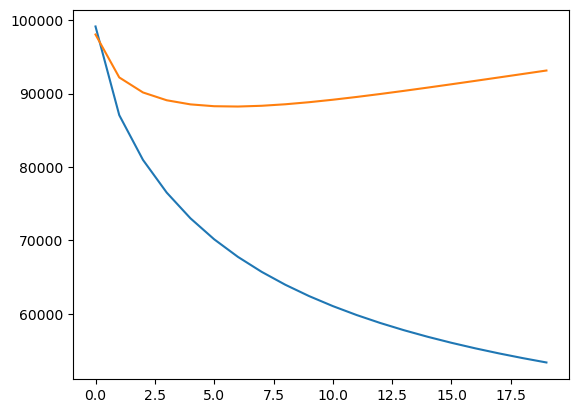

In [94]:
plt.plot(train_losses)
plt.plot(test_losses)

In [ ]:
#import matplotlib.pyplot as plt
#plt.plot(np.convolve(losses, np.ones(5), 'valid')/1000)


: 

In [205]:
losses[5]

3692139.5

In [197]:
np.array(losses)

array([2257820.    , 1932012.5   , 2449876.5   , ..., 2082323.5   ,
        460635.1875, 1233797.25  ], shape=(7000,))

In [ ]:
torch.norm(pred - targets, dim=)

tensor(11496.4219, grad_fn=<DotBackward0>)

In [81]:
W

tensor([[ 0.6607,  0.0059,  0.0018,  ...,  0.0029,  0.0067, -0.0092],
        [ 0.0121,  0.6251,  0.0007,  ...,  0.0260, -0.0128, -0.0042],
        [-0.0044,  0.0013,  0.6262,  ..., -0.0013, -0.0079, -0.0263],
        ...,
        [ 0.0062,  0.0157, -0.0113,  ...,  0.6269, -0.0063, -0.0278],
        [ 0.0135,  0.0027, -0.0038,  ..., -0.0141,  0.5675, -0.0239],
        [-0.0013,  0.0101, -0.0058,  ..., -0.0247, -0.0278,  0.6487]],
       requires_grad=True)

In [92]:
import numpy as np
with open('transformation_matrix_2.npy' , "wb") as f:
    np.save(f, W.detach().cpu().numpy())

In [53]:
with open('transformation_matrix.npy', 'rb') as f:
    transformation_matrix = np.load(f)

In [35]:
embeds_ = get_madlad_embedding("<2en> 你好", include_start_and_end_tokens=True)

In [15]:
generated = model.generate(inputs_embeds=embeds_)

In [16]:
tokenizer.decode(generated[0], skip_special_tokens=True)

'Hello.'

In [36]:
translation_token = get_madlad_embedding("<2en>")
text = "羅漢係我兄弟，他成日在正午放風箏，就算天陰陰"

for t in tokenizer('\b<2en>')['input_ids']:
    print(tokenizer.decode(t), t)

 805
 58531
<2en> 38
</s> 2


In [58]:
t = 10900
print(torch.norm(torch.tensor(transformation_matrix @ word2vec_model.wv[tokenizer.decode(t)]).unsqueeze(0)))
print(torch.norm(get_madlad_embedding_layer(1)))

tensor(6.5708)
tensor(207970.9688)


In [59]:
torch.norm(get_madlad_embedding(tokenizer.decode(t)))

tensor(339.8831)

In [100]:
text = "<2en>羅漢係我兄弟，他成日在正午放風箏，就算天陰陰"
#translation_token = get_madlad_embedding(text)

token_embeddings = []
for t in tokenizer(text)['input_ids']:
    #print(t)
    if tokenizer.decode(t) in word2vec_model.wv:
        #print(1)
        token_embedding = torch.tensor(word2vec_model.wv[tokenizer.decode(t)] @ transformation_matrix).unsqueeze(0)
    else:
        #print(2)
        token_embedding = get_madlad_embedding_layer(1)[t].unsqueeze(0)
        
    token_embeddings.append(torch.Tensor(token_embedding))
print(token_embeddings)
token_embeddings = torch.tensor(np.array([x.detach().cpu().numpy() for x in token_embeddings]))#.permute(1,0,2)

[tensor([[ 0.1655,  1.1890, -2.1539,  ..., -4.0582,  1.0744, -0.5774]]), tensor([[-3.9575e+00,  2.3815e-03,  1.6395e+00,  ...,  2.5391e+00,
         -1.6154e+01, -5.2441e+00]]), tensor([[ 0.2786, -0.0220, -0.2956,  ..., -0.1643,  0.1462, -0.2801]]), tensor([[ 0.1411, -0.1823, -0.4221,  ..., -0.0942,  0.1932,  0.0847]]), tensor([[-1.3523e-04, -2.0581e-01, -7.3519e-02,  ..., -1.6404e-01,
         -8.0244e-02,  3.9192e-02]]), tensor([[-0.0552, -0.0078,  0.1035,  ..., -0.0029,  0.0019,  0.0370]]), tensor([[-0.1698,  0.1402, -0.0519,  ..., -0.0746, -0.0947,  0.0488]]), tensor([[-0.1934, -0.1819,  0.1868,  ...,  0.1987, -0.0473, -0.4379]]), tensor([[-0.1313, -0.1198, -0.0662,  ..., -0.1960, -0.0077,  0.0999]]), tensor([[-0.4631, -0.0986, -0.2124,  ..., -0.1580, -0.2502, -0.2745]]), tensor([[ 0.1835,  0.0653,  0.0169,  ..., -0.1912, -0.0066,  0.0437]]), tensor([[ 0.3518,  0.0394, -0.0723,  ..., -0.3567, -0.1769,  0.0550]]), tensor([[-0.1107,  0.0798, -0.0971,  ...,  0.0352, -0.0668, -0.1245]]

In [101]:
token_embeddings.shape

torch.Size([25, 1, 1024])

In [102]:
token_embeddings

tensor([[[ 1.6555e-01,  1.1890e+00, -2.1539e+00,  ..., -4.0582e+00,
           1.0744e+00, -5.7736e-01]],

        [[-3.9575e+00,  2.3815e-03,  1.6395e+00,  ...,  2.5391e+00,
          -1.6154e+01, -5.2441e+00]],

        [[ 2.7861e-01, -2.2004e-02, -2.9561e-01,  ..., -1.6434e-01,
           1.4615e-01, -2.8010e-01]],

        ...,

        [[-3.7018e-01, -3.6549e-01, -2.5582e-01,  ..., -1.8197e-01,
           1.7310e-01, -3.3045e-02]],

        [[-3.7018e-01, -3.6549e-01, -2.5582e-01,  ..., -1.8197e-01,
           1.7310e-01, -3.3045e-02]],

        [[ 8.8776e-02,  7.7090e-01, -1.2226e+00,  ...,  6.7889e-01,
           8.6144e-01, -4.7935e-01]]])

In [159]:
model.encoder.embed_tokens(tokenizer(text,  return_tensors="pt").input_ids).shape

torch.Size([1, 25, 1024])

In [173]:
torch.all(token_embeddings == model.encoder.embed_tokens(tokenizer(text,  return_tensors="pt").input_ids))

tensor(True)

In [160]:
token_embeddings == model.encoder.embed_tokens(tokenizer(text,  return_tensors="pt").input_ids)

False

In [40]:
torch.tensor(np.array([x.detach().cpu().numpy() for x in token_embeddings]))

NameError: name 'token_embeddings' is not defined

In [102]:
model.encoder.embed_tokens(tokenizer(text,  return_tensors="pt").input_ids)

tensor([[[ 1.6555e-01,  1.1890e+00, -2.1539e+00,  ..., -4.0582e+00,
           1.0744e+00, -5.7736e-01],
         [-3.9575e+00,  2.3815e-03,  1.6395e+00,  ...,  2.5391e+00,
          -1.6154e+01, -5.2441e+00],
         [ 1.5735e+01,  1.1179e+01,  5.3661e+00,  ...,  8.9747e+00,
          -1.1488e+01, -1.1491e+01],
         ...,
         [ 2.3343e+00,  3.2717e+01,  7.6224e+00,  ...,  2.3185e+00,
          -1.1847e+01, -1.5596e+00],
         [ 2.3343e+00,  3.2717e+01,  7.6224e+00,  ...,  2.3185e+00,
          -1.1847e+01, -1.5596e+00],
         [ 8.8776e-02,  7.7090e-01, -1.2226e+00,  ...,  6.7889e-01,
           8.6144e-01, -4.7935e-01]]], grad_fn=<EmbeddingBackward0>)

In [68]:
torch.tensor(token_embeddings)

ValueError: only one element tensors can be converted to Python scalars

In [54]:
torch.stack(token_embeddings).shape

torch.Size([25, 1, 1024])

In [58]:
torch.mean(torch.stack(token_embeddings), dim=0).shape

torch.Size([1, 1024])

In [59]:
output = model.generate(inputs_embeds=torch.mean(torch.stack(token_embeddings).unsqueeze(0), dim=0))

In [182]:
out = model.generate(inputs_embeds=token_embeddings)
tokenizer.decode(out[0], skip_special_tokens=True)

'I i k ets tn y k s y y t a t y y'

In [106]:
true_embeds = model.encoder.embed_tokens(tokenizer(text,return_tensors="pt").input_ids)

In [ ]:
true_embeds = model.encoder.embed_tokens(tokenizer(text,return_tensors="pt").input_ids)
z = model.generate(inputs_embeds=true_embeds)
tokenizer.decode(z[0], skip_special_tokens=True)

'Rohan is my brother, he flies kites at noon every day, even in the dark'

In [85]:
tokenizer.decode(out[0], skip_special_tokens=True)

'Rohan is my brother, he is a rocket, he is a rocket, he is'

In [81]:
z = model.generate(tokenizer(text, return_tensors="pt").input_ids.to(model.device))
tokenizer.decode(z[0], skip_special_tokens=True)

'Rohan is my brother, he flies kites at noon every day, even in the dark'